In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy import stats
import pickle
import json

In [28]:
df = pd.read_csv('data/Extended_Employee_Performance_and_Productivity_Data.csv')
print(df.head(3))
df.describe()

   Employee_ID Department Gender  Age   Job_Title                   Hire_Date  \
0            1         IT   Male   55  Specialist  2022-01-19 08:03:05.556036   
1            2    Finance   Male   29   Developer  2024-04-18 08:03:05.556036   
2            3    Finance   Male   55  Specialist  2015-10-26 08:03:05.556036   

   Years_At_Company Education_Level  Performance_Score  Monthly_Salary  \
0                 2     High School                  5          6750.0   
1                 0     High School                  5          7500.0   
2                 8     High School                  3          5850.0   

   Work_Hours_Per_Week  Projects_Handled  Overtime_Hours  Sick_Days  \
0                   33                32              22          2   
1                   34                34              13         14   
2                   37                27               6          3   

   Remote_Work_Frequency  Team_Size  Training_Hours  Promotions  \
0                      0  

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


## Create Target Variable

In [29]:
df['Good_Coordination'] = (df['Performance_Score'] >= 3).astype(int)

true_count = df['Good_Coordination'].sum()
false_count = (df['Good_Coordination'] == 0).sum()
total = len(df)

print("TRUE (Good_Coordination):", true_count, f"({true_count/total*100:.1f}%)")
print("FALSE (Good_Coordination):", false_count, f"({false_count/total*100:.1f}%)")

TRUE (Good_Coordination): 59867 (59.9%)
FALSE (Good_Coordination): 40133 (40.1%)


## Select Features

In [30]:
features = [
    'Projects_Handled',
    'Training_Hours',
    'Team_Size',
    'Work_Hours_Per_Week',
    'Overtime_Hours',
    'Employee_Satisfaction_Score',
    'Sick_Days',
    'Years_At_Company'
]

X = df[features]
y = df['Good_Coordination']

print("X shape:", X.shape)

X shape: (100000, 8)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

# Scaler data for Logistic Regression and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 80000
Testing rows: 20000


# Logistic Regression 

In [32]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
print("1. Logistic Regression :", round(lr_acc*100,2), "%")

lr_pred_train = lr_model.predict(X_train_scaled)
lr_acc_train = accuracy_score(y_train, lr_pred_train)
print("3. Logistic Regression train        :", round(lr_acc_train * 100, 2), "%")

1. Logistic Regression : 59.3 %
3. Logistic Regression train        : 60.01 %


# Decision Tree

In [33]:
dt_model = DecisionTreeClassifier(random_state=42,max_depth=5)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
print("2. Decision Tree        :", round(dt_acc * 100, 2), "%")

dt_pred_train = dt_model.predict(X_train)
dt_acc_train = accuracy_score(y_train, dt_pred_train)
print("3. Decision Tree train        :", round(dt_acc_train * 100, 2), "%")

2. Decision Tree        : 59.1 %
3. Decision Tree train        : 60.1 %


# Random Forest

In [34]:
rf_model = RandomForestClassifier(n_estimators=100,max_depth=10, min_samples_leaf=5, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("3. Random Forest        :", round(rf_acc * 100, 2), "%")

rf_pred_train = rf_model.predict(X_train)
rf_acc_train = accuracy_score(y_train, rf_pred_train)
print("3. Random Forest train        :", round(rf_acc_train * 100, 2), "%")

3. Random Forest        : 59.3 %
3. Random Forest train        : 60.16 %


# Gradient Boosting

In [35]:
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
print("4. Gradient Boosting    :", round(gb_acc * 100, 2), "%")

4. Gradient Boosting    : 59.28 %


# SVM

In [36]:
svm_model = SVC(random_state=42, kernel='linear')
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM :",round(svm_acc * 100, 2), "%")

svm_pred_train = svm_model.predict(X_train_scaled)
svm_acc_train = accuracy_score(y_train, svm_pred_train)
print("3. SVM train        :", round(svm_acc_train * 100, 2), "%")

SVM : 59.3 %
3. SVM train        : 60.01 %


# Find Best Model

In [37]:
model_results = {
    'Logistic Regression': lr_acc,
    'Decision Tree': dt_acc,
    'Random Forest': rf_acc,
    'Gradient Boosting': gb_acc,
    'SVM': svm_acc
}

best_model_name = max(model_results, key=model_results.get)
best_accuracy = model_results[best_model_name]

# Model comparison
for name, acc in model_results.items():
    marker = "<-- Best" if name == best_model_name else "" 
    print(f" {name:25s}: {round(acc*100, 2)}%{marker}")

print("Best Model :", best_model_name)
print("Accuracy :", round(best_accuracy * 100,2), "%")

 Logistic Regression      : 59.3%<-- Best
 Decision Tree            : 59.1%
 Random Forest            : 59.3%
 Gradient Boosting        : 59.28%
 SVM                      : 59.3%
Best Model : Logistic Regression
Accuracy : 59.3 %


In [38]:
df['Task_Load'] = pd.cut(
    df['Projects_Handled'],
    bins= [-1, 15, 30, 49],
    labels= ['Low', 'Medium', 'High']
)

hypothesis_results = {}

# One sample T-Test
# Ho : Mean Performance_Score <= 3
# H1 : Mean Performance_Score > 3
# Alpha = 0.05

t_stat,p_value = stats.ttest_1samp(
    df['Performance_Score'],
    popmean=3
)
# Convert to one tailed p-value
if t_stat > 0:
    p_one_tailed = p_value/2
else:
    p_one_tailed = 1-(p_value/2)


if p_one_tailed <= 0.05:
    print(round(p_one_tailed, 6))
    print("Decision : Reject Ho, The mean Performance_Score is significantly > 3 at 5% level of significence")
    print()
    print("Conclusion: Employees are performing ABOVE the average, Team coordination is proven to be GOOD.")

elif p_one_tailed > 0.05:
    print(round(p_one_tailed, 6))
    print("Decision : Do not Reject Ho, The mean Performance_Score is significantly <= 3 at 5% level of significence")
    print()
    print("Conclusion: Employees are performing Below the average, Team coordination is proven to be NOT GOOD.")

H_decision = "Reject H0" if p_one_tailed < 0.05 else "Fail to Reject H0"

hypothesis_results['H2_OneSampleT'] = {
    'test': 'One-sample t',
    'p_value' : round(p_one_tailed, 6),
    'decision' : H_decision
}

0.846493
Decision : Do not Reject Ho, The mean Performance_Score is significantly <= 3 at 5% level of significence

Conclusion: Employees are performing Below the average, Team coordination is proven to be NOT GOOD.


## Discriptive Analysis

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

Style Settings

In [40]:
plt.rcParams['figure.facecolor'] = '#0a0e1a'
plt.rcParams['axes.facecolor']   = '#131c35'
plt.rcParams['axes.edgecolor']   = '#00e5ff'
plt.rcParams['text.color']       = '#e2e8f0'
plt.rcParams['axes.labelcolor']  = '#e2e8f0'
plt.rcParams['xtick.color']      = '#e2e8f0'
plt.rcParams['ytick.color']      = '#e2e8f0'
plt.rcParams['grid.color']       = '#1e2a4a'
plt.rcParams['grid.alpha']       = 0.5
 
ACCENT  = '#00e5ff'
GREEN   = '#10b981'
RED     = '#ef4444'
PURPLE  = '#7c3aed'
ORANGE  = '#f59e0b'
COLORS  = [ACCENT, GREEN, RED, PURPLE, ORANGE,
           '#3b82f6', '#ec4899', '#14b8a6', '#f97316']

Basic Statistics Summary

In [41]:
stats = df[features + ['Performance_Score']].describe().round(3)
print(stats.to_string())

print("\nSkewness (how much data is skewed):")
for col in features + ['Performance_Score']:
    skew = df[col].skew()
    direction = "Right skewed ➡️" if skew > 0.5 else "Left skewed ⬅️" if skew < -0.5 else "Normal ✅"
    print(f"  {col:35s}: {skew:7.4f}  {direction}")

       Projects_Handled  Training_Hours   Team_Size  Work_Hours_Per_Week  Overtime_Hours  Employee_Satisfaction_Score   Sick_Days  Years_At_Company  Performance_Score
count        100000.000      100000.000  100000.000           100000.000      100000.000                   100000.000  100000.000        100000.000         100000.000
mean             24.431          49.506      10.014               44.957          14.515                        2.999       7.009             4.476              2.995
std              14.470          28.890       5.495                8.942           8.664                        1.151       4.332             2.869              1.415
min               0.000           0.000       1.000               30.000           0.000                        1.000       0.000             0.000              1.000
25%              12.000          25.000       5.000               37.000           7.000                        2.010       3.000             2.000              2.00

Histogram

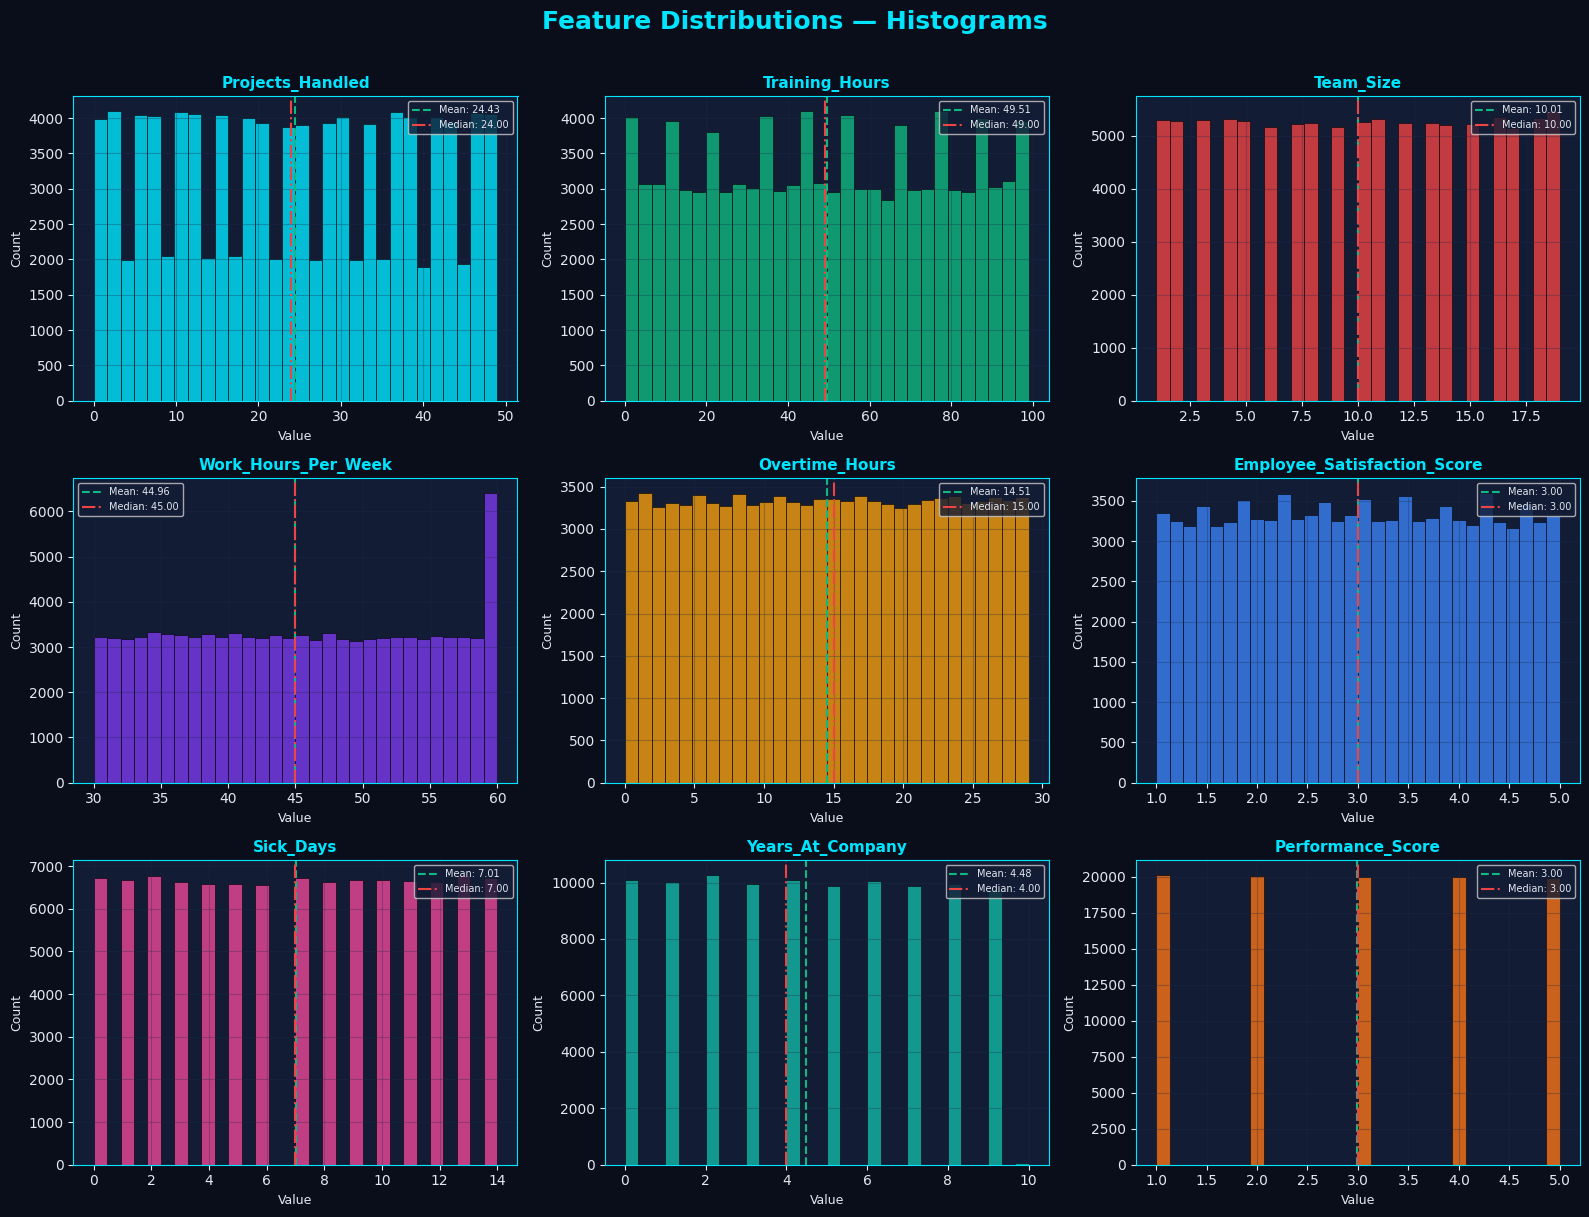

Saved: plots/01_histograms.png ✅


In [42]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Feature Distributions — Histograms',
             fontsize=18, fontweight='bold', color=ACCENT, y=1.01)
 
all_cols = features + ['Performance_Score']
 
for idx, col in enumerate(all_cols):
    ax  = axes[idx // 3][idx % 3]
    color = COLORS[idx % len(COLORS)]
 
    ax.hist(df[col], bins=30, color=color, alpha=0.8,
            edgecolor='black', linewidth=0.5)
 
    # Add mean and median lines
    mean_val   = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val,   color=GREEN,  linestyle='--',
               linewidth=1.5, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color=RED,    linestyle='-.',
               linewidth=1.5, label=f'Median: {median_val:.2f}')
 
    ax.set_title(col, fontsize=11, fontweight='bold', color=ACCENT)
    ax.set_xlabel('Value',   fontsize=9)
    ax.set_ylabel('Count',   fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('plots/01_histograms.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("Saved: plots/01_histograms.png ✅")

Boxplot

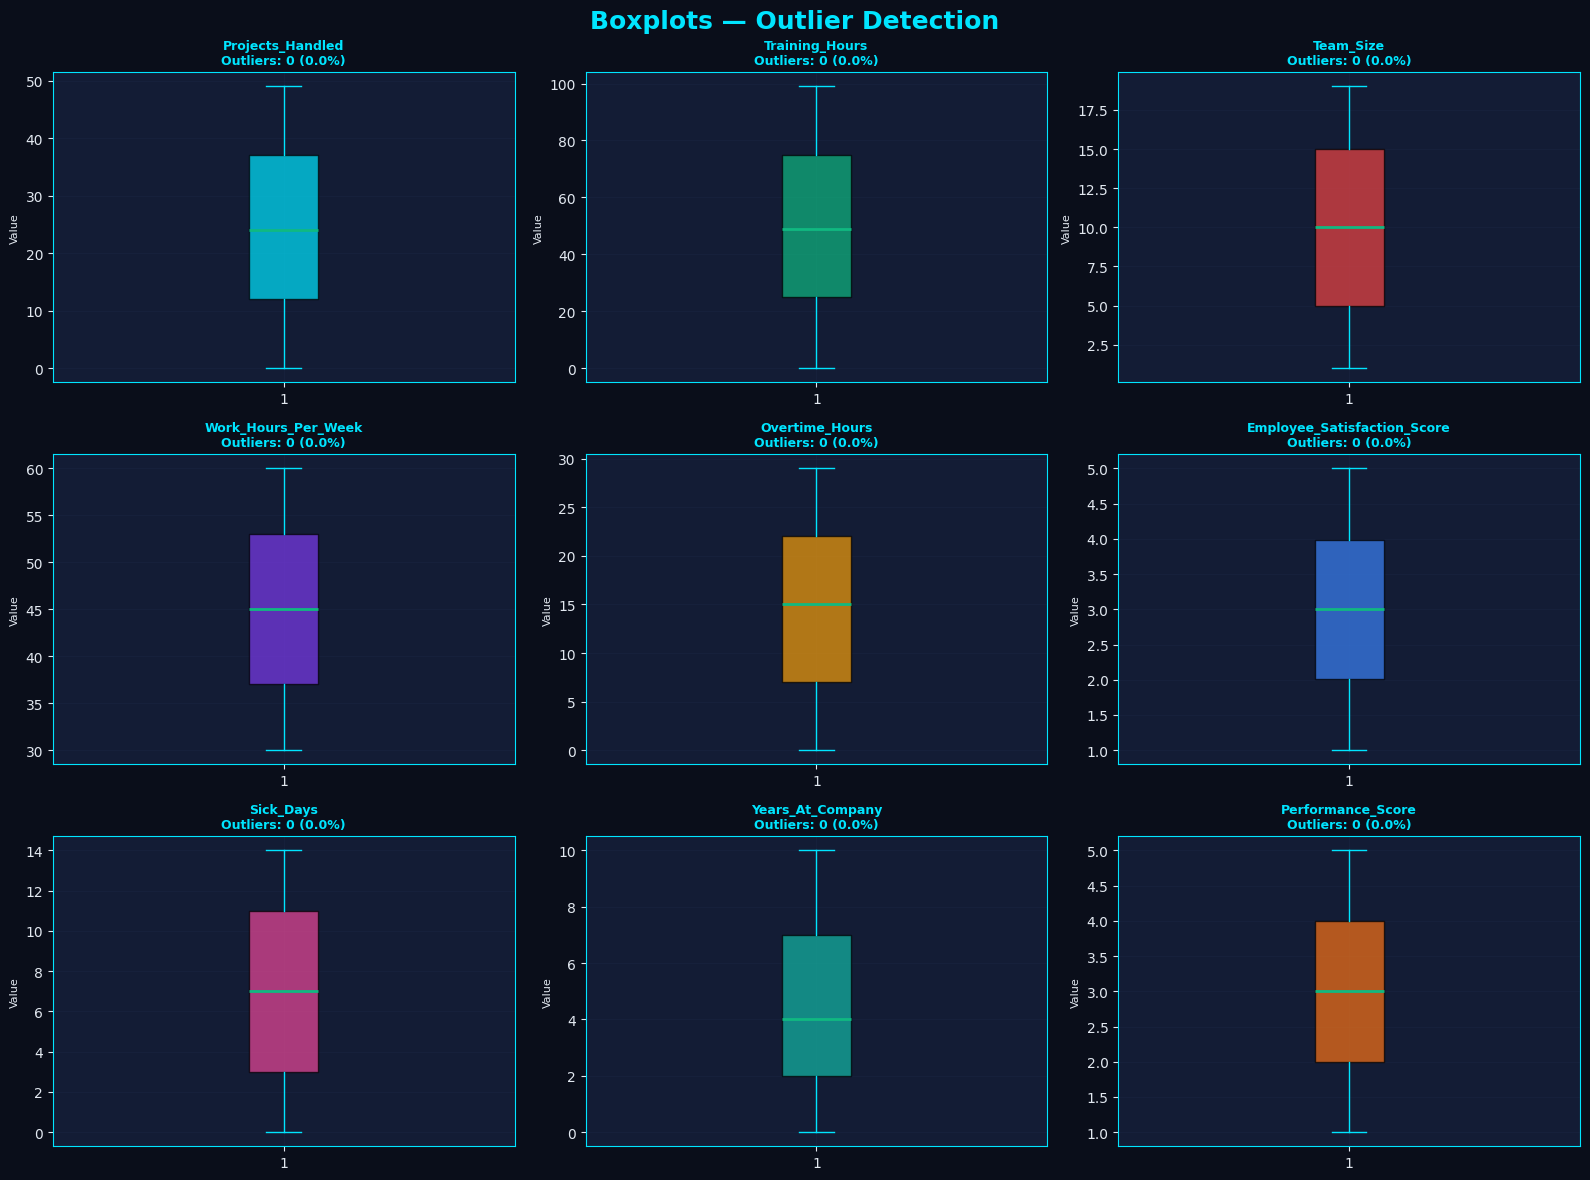

Saved: plots/02_boxplots.png ✅

OUTLIER SUMMARY (IQR Method):
Feature                               Outliers    Percent      Lower      Upper
--------------------------------------------------------------------------------
  Projects_Handled                           0      0.00%      -25.5       74.5  ✅ Normal
  Training_Hours                             0      0.00%      -50.0      150.0  ✅ Normal
  Team_Size                                  0      0.00%      -10.0       30.0  ✅ Normal
  Work_Hours_Per_Week                        0      0.00%       13.0       77.0  ✅ Normal
  Overtime_Hours                             0      0.00%      -15.5       44.5  ✅ Normal
  Employee_Satisfaction_Score                0      0.00%      -0.96       6.96  ✅ Normal
  Sick_Days                                  0      0.00%       -9.0       23.0  ✅ Normal
  Years_At_Company                           0      0.00%       -5.5       14.5  ✅ Normal
  Performance_Score                          0      0.00%

In [43]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Boxplots — Outlier Detection',
             fontsize=18, fontweight='bold', color=ACCENT)
 
outlier_summary = {}
 
for idx, col in enumerate(all_cols):
    ax    = axes[idx // 3][idx % 3]
    color = COLORS[idx % len(COLORS)]
 
    # Calculate outliers using IQR method
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers    = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = len(outliers) / len(df) * 100
 
    outlier_summary[col] = {
        'count'  : len(outliers),
        'pct'    : round(outlier_pct, 2),
        'Q1'     : round(Q1, 3),
        'Q3'     : round(Q3, 3),
        'IQR'    : round(IQR, 3),
        'lower'  : round(lower_bound, 3),
        'upper'  : round(upper_bound, 3)
    }
 
    bp = ax.boxplot(df[col], patch_artist=True,
                    medianprops=dict(color=GREEN, linewidth=2),
                    whiskerprops=dict(color=ACCENT),
                    capprops=dict(color=ACCENT),
                    flierprops=dict(marker='o', markerfacecolor=RED,
                                   markersize=3, alpha=0.5))
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
 
    ax.set_title(f'{col}\nOutliers: {len(outliers):,} ({outlier_pct:.1f}%)',
                 fontsize=9, fontweight='bold', color=ACCENT)
    ax.set_ylabel('Value', fontsize=8)
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('plots/02_boxplots.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("Saved: plots/02_boxplots.png ✅")
 
print("\nOUTLIER SUMMARY (IQR Method):")
print(f"{'Feature':<35} {'Outliers':>10} {'Percent':>10} {'Lower':>10} {'Upper':>10}")
print("-" * 80)
for col, info in outlier_summary.items():
    status = "⚠️ High" if info['pct'] > 5 else "✅ Normal"
    print(f"  {col:<33} {info['count']:>10,} {info['pct']:>9.2f}%"
          f" {info['lower']:>10} {info['upper']:>10}  {status}")

PERFORMANCE SCORE DISTRIBUTION

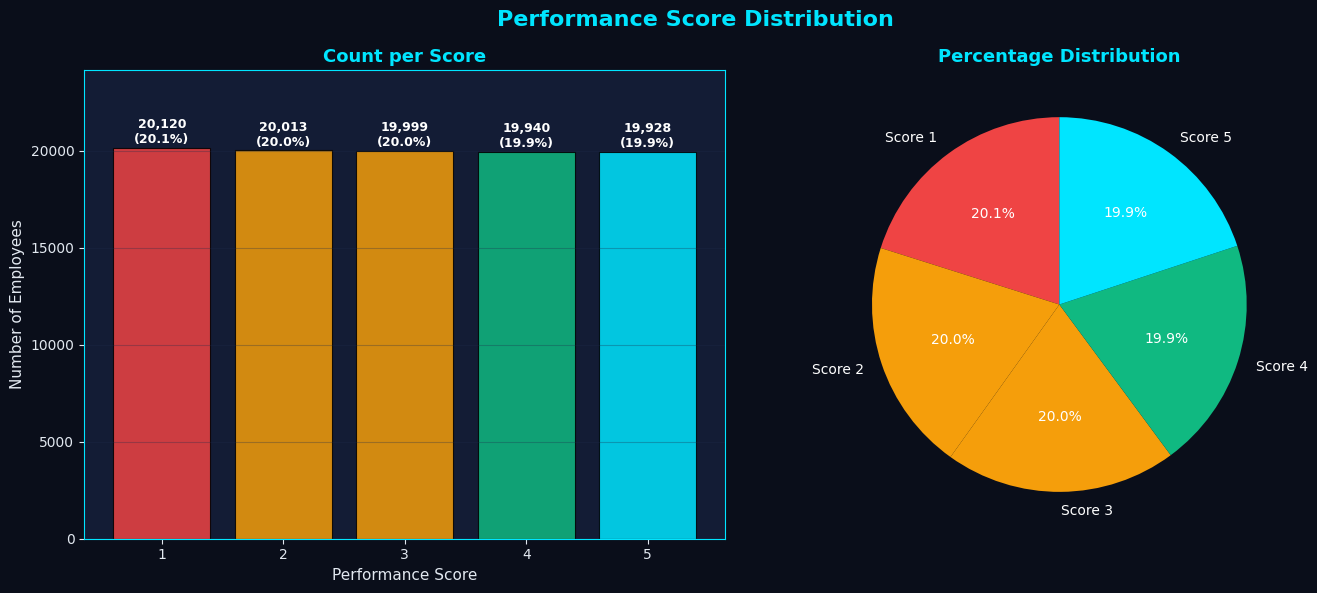

Saved: plots/03_performance_distribution.png ✅

Performance Score Stats:
  Mean   : 2.9954
  Median : 3.0000
  Std    : 1.4147
  Min    : 1
  Max    : 5


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Performance Score Distribution',
             fontsize=16, fontweight='bold', color=ACCENT)
 
# Bar chart
perf_dist  = df['Performance_Score'].value_counts().sort_index()
bar_colors = [RED, ORANGE, '#f59e0b', GREEN, ACCENT]
 
bars = axes[0].bar(perf_dist.index, perf_dist.values,
                   color=bar_colors, edgecolor='black',
                   linewidth=0.8, alpha=0.85)
axes[0].set_title('Count per Score', fontsize=13,
                  fontweight='bold', color=ACCENT)
axes[0].set_xlabel('Performance Score', fontsize=11)
axes[0].set_ylabel('Number of Employees', fontsize=11)
 
for bar, val in zip(bars, perf_dist.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 100,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom',
                 fontsize=9, color='white', fontweight='bold')
 
axes[0].set_ylim(0, max(perf_dist.values) * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')
 
# Pie chart
labels = [f'Score {i}' for i in perf_dist.index]
axes[1].pie(perf_dist.values, labels=labels,
            colors=bar_colors, autopct='%1.1f%%',
            startangle=90, textprops={'color': 'white', 'fontsize': 10})
axes[1].set_title('Percentage Distribution',
                  fontsize=13, fontweight='bold', color=ACCENT)
 
plt.tight_layout()
plt.savefig('plots/03_performance_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("Saved: plots/03_performance_distribution.png ✅")
 
# Print stats
print(f"\nPerformance Score Stats:")
print(f"  Mean   : {df['Performance_Score'].mean():.4f}")
print(f"  Median : {df['Performance_Score'].median():.4f}")
print(f"  Std    : {df['Performance_Score'].std():.4f}")
print(f"  Min    : {df['Performance_Score'].min()}")
print(f"  Max    : {df['Performance_Score'].max()}")

DEPARTMENT ANALYSIS

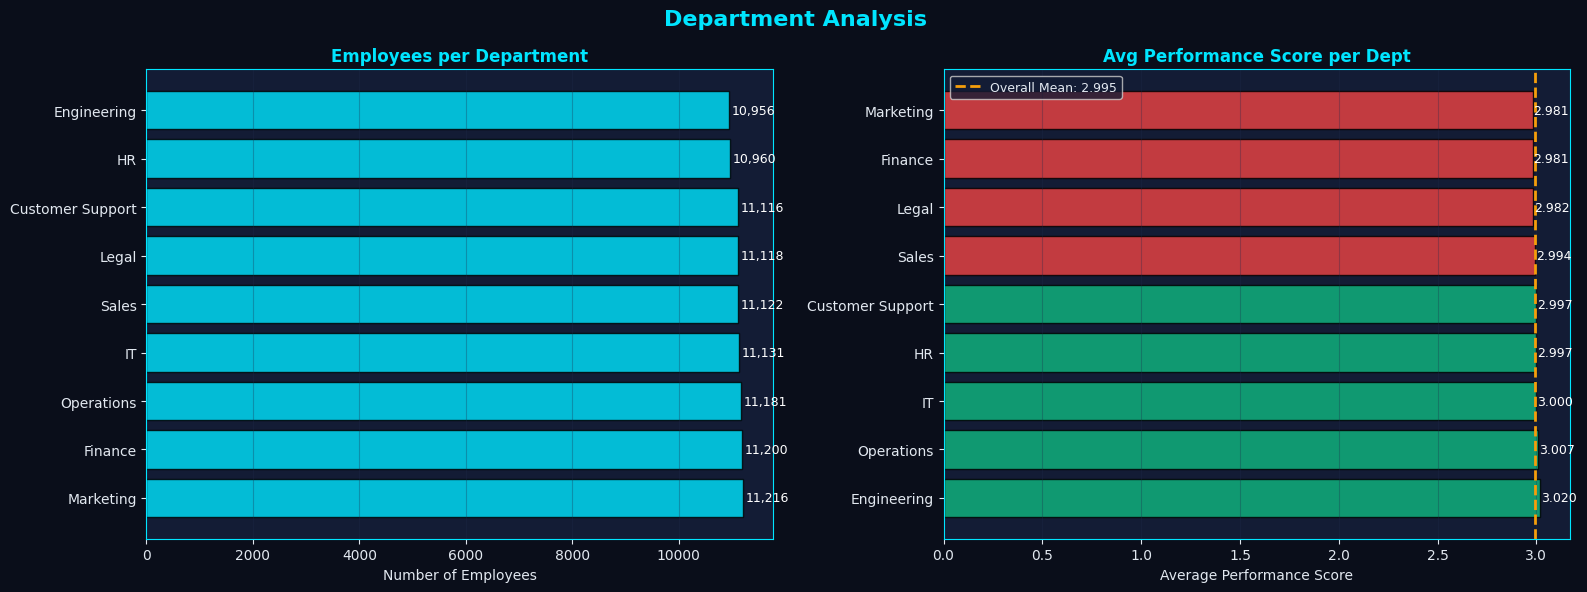

Saved: plots/04_department_analysis.png ✅


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Department Analysis',
             fontsize=16, fontweight='bold', color=ACCENT)
 
dept_count = df['Department'].value_counts()
dept_perf  = df.groupby('Department')['Performance_Score'].mean().sort_values(ascending=False)
 
# Employee count per department
bars = axes[0].barh(dept_count.index, dept_count.values,
                    color=ACCENT, alpha=0.8, edgecolor='black')
axes[0].set_title('Employees per Department',
                  fontsize=12, fontweight='bold', color=ACCENT)
axes[0].set_xlabel('Number of Employees', fontsize=10)
for bar, val in zip(bars, dept_count.values):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9, color='white')
axes[0].grid(True, alpha=0.3, axis='x')
 
# Average performance per department
colors_dept = [GREEN if v >= dept_perf.mean() else RED for v in dept_perf.values]
bars2 = axes[1].barh(dept_perf.index, dept_perf.values,
                     color=colors_dept, alpha=0.8, edgecolor='black')
axes[1].axvline(dept_perf.mean(), color=ORANGE, linestyle='--',
                linewidth=2, label=f'Overall Mean: {dept_perf.mean():.3f}')
axes[1].set_title('Avg Performance Score per Dept',
                  fontsize=12, fontweight='bold', color=ACCENT)
axes[1].set_xlabel('Average Performance Score', fontsize=10)
axes[1].legend(fontsize=9)
for bar, val in zip(bars2, dept_perf.values):
    axes[1].text(bar.get_width() + 0.005,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9, color='white')
axes[1].grid(True, alpha=0.3, axis='x')
 
plt.tight_layout()
plt.savefig('plots/04_department_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("Saved: plots/04_department_analysis.png ✅")

TASK LOAD ANALYSIS

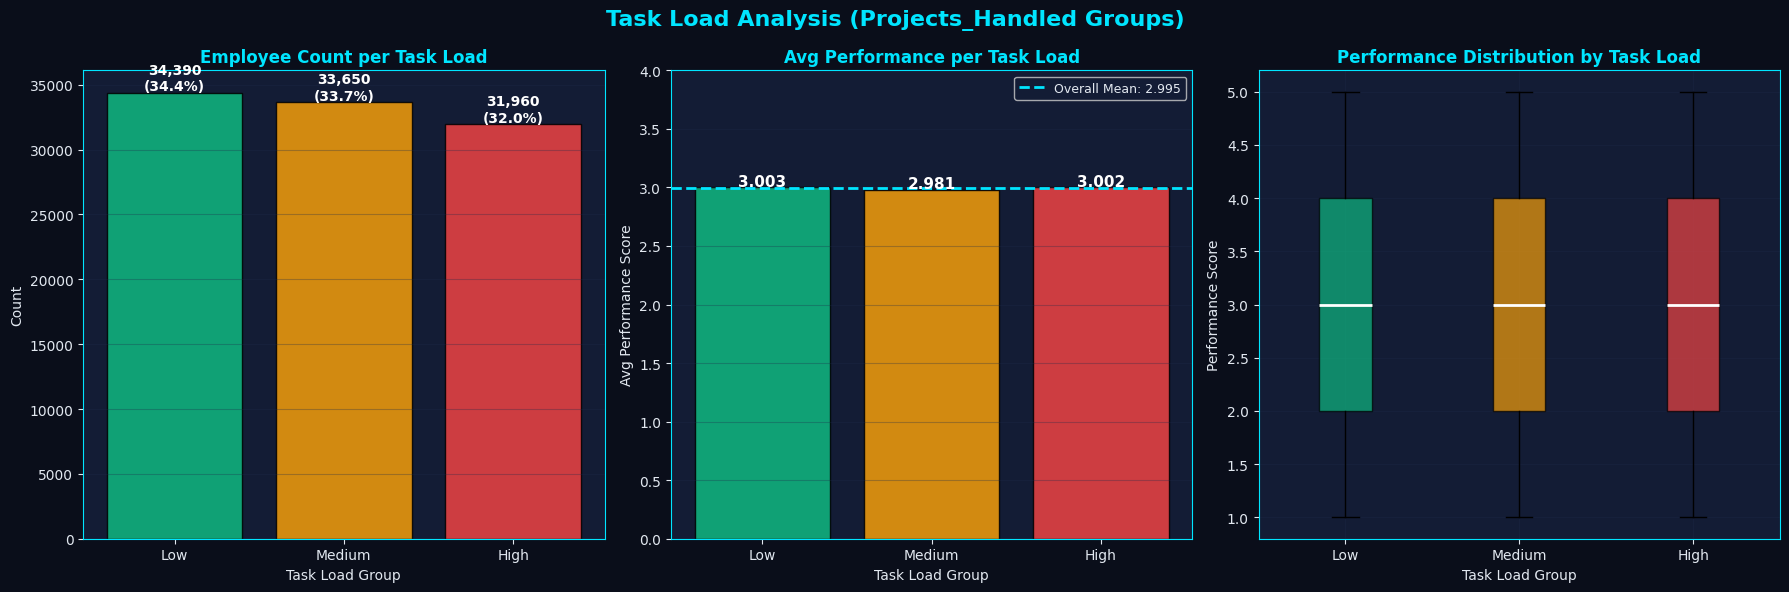

Saved: plots/05_task_load_analysis.png ✅

Task Load Group Stats:
  Low     : 34,390 employees | Avg Performance: 3.0032
  Medium  : 33,650 employees | Avg Performance: 2.9810
  High    : 31,960 employees | Avg Performance: 3.0023


In [46]:
# Create Task_Load categories based on Projects_Handled
df['Task_Load'] = pd.cut(df['Projects_Handled'], 
                         bins=[df['Projects_Handled'].min()-1, 
                               df['Projects_Handled'].quantile(0.33), 
                               df['Projects_Handled'].quantile(0.67), 
                               df['Projects_Handled'].max()],
                         labels=['Low', 'Medium', 'High'])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Task Load Analysis (Projects_Handled Groups)',
             fontsize=16, fontweight='bold', color=ACCENT)
 
task_colors = [GREEN, ORANGE, RED]
task_groups = ['Low', 'Medium', 'High']
 
# Count per task load
task_count = df['Task_Load'].value_counts()[task_groups]
axes[0].bar(task_groups, task_count.values,
            color=task_colors, alpha=0.85, edgecolor='black')
axes[0].set_title('Employee Count per Task Load',
                  fontsize=12, fontweight='bold', color=ACCENT)
axes[0].set_xlabel('Task Load Group', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
for i, val in enumerate(task_count.values):
    axes[0].text(i, val + 200, f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, color='white', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
 
# Avg performance per task load
task_perf = df.groupby('Task_Load', observed=True)['Performance_Score'].mean()[task_groups]
bars = axes[1].bar(task_groups, task_perf.values,
                   color=task_colors, alpha=0.85, edgecolor='black')
axes[1].axhline(df['Performance_Score'].mean(), color=ACCENT,
                linestyle='--', linewidth=2,
                label=f'Overall Mean: {df["Performance_Score"].mean():.3f}')
axes[1].set_title('Avg Performance per Task Load',
                  fontsize=12, fontweight='bold', color=ACCENT)
axes[1].set_xlabel('Task Load Group', fontsize=10)
axes[1].set_ylabel('Avg Performance Score', fontsize=10)
axes[1].legend(fontsize=9)
for bar, val in zip(bars, task_perf.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center',
                 fontsize=11, color='white', fontweight='bold')
axes[1].set_ylim(0, 4)
axes[1].grid(True, alpha=0.3, axis='y')
 
# Boxplot of performance by task load
data_by_load = [
    df[df['Task_Load'] == grp]['Performance_Score'].values
    for grp in task_groups
]
bp = axes[2].boxplot(data_by_load, patch_artist=True,
                     labels=task_groups,
                     medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], task_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Performance Distribution by Task Load',
                  fontsize=12, fontweight='bold', color=ACCENT)
axes[2].set_xlabel('Task Load Group', fontsize=10)
axes[2].set_ylabel('Performance Score', fontsize=10)
axes[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('plots/05_task_load_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("Saved: plots/05_task_load_analysis.png ✅")
 
print("\nTask Load Group Stats:")
for grp in task_groups:
    grp_df   = df[df['Task_Load'] == grp]
    avg_perf = grp_df['Performance_Score'].mean()
    count    = len(grp_df)
    print(f"  {grp:8s}: {count:,} employees | Avg Performance: {avg_perf:.4f}")

SCATTER PLOTS 

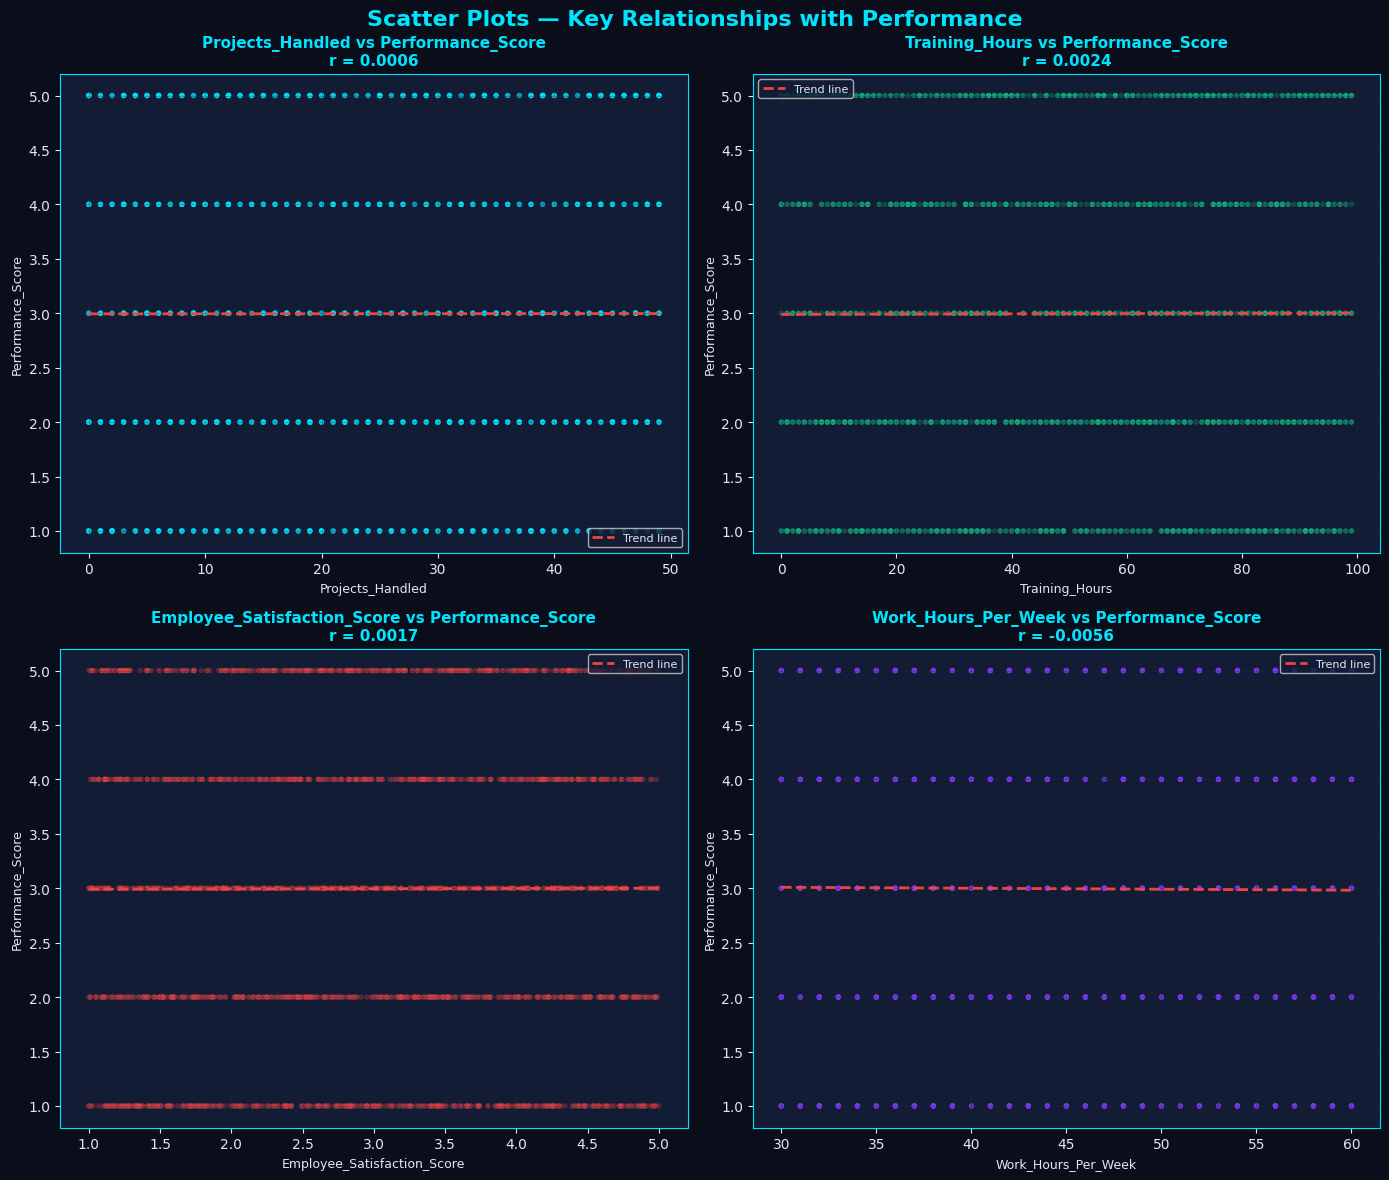

Saved: plots/08_scatter_plots.png ✅


In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Scatter Plots — Key Relationships with Performance',
             fontsize=16, fontweight='bold', color=ACCENT)
 
scatter_pairs = [
    ('Projects_Handled',          'Performance_Score'),
    ('Training_Hours',            'Performance_Score'),
    ('Employee_Satisfaction_Score','Performance_Score'),
    ('Work_Hours_Per_Week',       'Performance_Score'),
]
 
for idx, (x_col, y_col) in enumerate(scatter_pairs):
    ax    = axes[idx // 2][idx % 2]
    color = COLORS[idx]
 
    # Sample 2000 points for readability
    sample = df.sample(2000, random_state=42)
 
    ax.scatter(sample[x_col], sample[y_col],
               alpha=0.3, color=color, s=15, edgecolors='none')
 
    # Add trend line
    z = np.polyfit(df[x_col], df[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_line, p(x_line), color=RED,
            linewidth=2, linestyle='--', label='Trend line')
 
    corr = df[x_col].corr(df[y_col])
    ax.set_title(f'{x_col} vs {y_col}\nr = {corr:.4f}',
                 fontsize=11, fontweight='bold', color=ACCENT)
    ax.set_xlabel(x_col,  fontsize=9)
    ax.set_ylabel(y_col,  fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('plots/08_scatter_plots.png', dpi=150,
            bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("Saved: plots/08_scatter_plots.png ✅")

OUTLIER SUMMARY TABLE

In [48]:
print(f"\n{'Feature':<35} {'Q1':>8} {'Q3':>8} {'IQR':>8} "
      f"{'Lower':>10} {'Upper':>10} {'Outliers':>10} {'Pct':>8}")
print("-" * 100)
 
total_outliers = 0
for col in features + ['Performance_Score']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lb  = Q1 - 1.5 * IQR
    ub  = Q3 + 1.5 * IQR
    n   = len(df[(df[col] < lb) | (df[col] > ub)])
    pct = n / len(df) * 100
    total_outliers += n
    flag = "⚠️" if pct > 5 else "✅"
    print(f"  {col:<33} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} "
          f"{lb:>10.2f} {ub:>10.2f} {n:>10,} {pct:>7.2f}%  {flag}")
 
print("-" * 100)
print(f"\nOUTLIER INTERPRETATION:")
print(f"  IQR Method: values below Q1-1.5*IQR or above Q3+1.5*IQR")
print(f"  ✅ = Less than 5% outliers (acceptable)")
print(f"  ⚠️ = More than 5% outliers (investigate)")
print(f"\nNOTE: With 100,000 rows, small % outliers")
print(f"      still mean many absolute rows.")
print(f"      For ML models, outliers have minimal")
print(f"      impact due to large dataset size. ✅")
 


Feature                                   Q1       Q3      IQR      Lower      Upper   Outliers      Pct
----------------------------------------------------------------------------------------------------
  Projects_Handled                     12.00    37.00    25.00     -25.50      74.50          0    0.00%  ✅
  Training_Hours                       25.00    75.00    50.00     -50.00     150.00          0    0.00%  ✅
  Team_Size                             5.00    15.00    10.00     -10.00      30.00          0    0.00%  ✅
  Work_Hours_Per_Week                  37.00    53.00    16.00      13.00      77.00          0    0.00%  ✅
  Overtime_Hours                        7.00    22.00    15.00     -15.50      44.50          0    0.00%  ✅
  Employee_Satisfaction_Score           2.01     3.99     1.98      -0.96       6.96          0    0.00%  ✅
  Sick_Days                             3.00    11.00     8.00      -9.00      23.00          0    0.00%  ✅
  Years_At_Company                   

# Hypothesis Testing

# Correlation matrix

In [49]:
corr_freature = [
    'Projects_Handled',
    'Training_Hours',
    'Team_Size',
    'Work_Hours_Per_Week',
    'Overtime_Hours',
    'Employee_Satisfaction_Score',
    'Sick_Days',
    'Years_At_Company',
    'Performance_Score' 
]

# calculate correlation matrix
corr_matrix = df[corr_freature].corr()
print(corr_matrix.round(4))

# correlation with performance score
perf_corr = corr_matrix['Performance_Score'].drop('Performance_Score')
perf_corr = perf_corr.sort_values(ascending=False)

for feature, corr_val in perf_corr.items():
    if corr_val >= 0.3:
        strength = "Strong"
    elif corr_val >= 0.1:
        strength = "Moderate"
    elif corr_val >= 0:
        strength = "Weak"
    else:
        strength = "Negative"
    print(f"{feature:35s}: {round(corr_val, 4):>8} | {strength}")

# projects_handled specifically
proj_corr = corr_matrix['Performance_Score']['Projects_Handled']
print(f"Projects_Handled vs Performance_Score: {round(proj_corr, 4)}")

if proj_corr > 0.3:
    print("Strong positive correlation")
    print("Topic is STRONGLY supported")
elif proj_corr > 0.1:
    print("Moderate positive correlation")
    print("Topic is SUPPORTED")
elif proj_corr > 0:
    print("Weak positive correlation")
    print("Topic is WEAKLY supported")
else:
    print("Negative or no correlation")
    print("Topic is NOT supported")

                             Projects_Handled  Training_Hours  Team_Size  \
Projects_Handled                       1.0000          0.0022     0.0038   
Training_Hours                         0.0022          1.0000     0.0027   
Team_Size                              0.0038          0.0027     1.0000   
Work_Hours_Per_Week                   -0.0042          0.0013     0.0008   
Overtime_Hours                         0.0041          0.0029     0.0022   
Employee_Satisfaction_Score            0.0061         -0.0015     0.0009   
Sick_Days                             -0.0050          0.0003     0.0001   
Years_At_Company                       0.0030          0.0027     0.0032   
Performance_Score                      0.0006          0.0024    -0.0052   

                             Work_Hours_Per_Week  Overtime_Hours  \
Projects_Handled                         -0.0042          0.0041   
Training_Hours                            0.0013          0.0029   
Team_Size                          

In [50]:
# Save correlation dta to ressults.json
corr_dict = {}
for feature in corr_freature:
    corr_dict[feature] = {}
    for feature2 in corr_freature:
        corr_dict[feature][feature2] = round(
            float(corr_matrix[feature][feature2]), 4
        )

# Save Performance_Score correlations for website
perf_corr_dict = {}
for feature, val in perf_corr.items():
    perf_corr_dict[feature] = round(float(val), 4)

print("\nCorrelation data ready to save!")
print("Projects_Handled correlation:", round(proj_corr, 4))


Correlation data ready to save!
Projects_Handled correlation: 0.0006


Save Everythings

In [54]:
pickle.dump(rf_model, open('ml_model.pkl', 'wb'))
pickle.dump(scaler, open('ml_model.pkl', 'wb'))
print("ml_model.pkl saved!")

# fearture importance from Random Forest
importance_values = rf_model.feature_importances_
feat_importance = {}
for i, f in enumerate(features):
    feat_importance[f] = round(float(importance_values[i]), 4)

feat_importance = dict(
    sorted(feat_importance.items(), key=lambda x: x[1], reverse=True)
)

# Save results as JSON for website

df['Task_Load'] = pd.cut(
    df['Projects_Handled'],
    bins   = [-1, 15, 30, 49],
    labels = ['Low', 'Medium', 'High']
)

desc_stats = {
    'mean_performance'  : round(float(df['Performance_Score'].mean()), 4),
    'mean_projects'     : round(float(df['Projects_Handled'].mean()), 2),
    'mean_work_hours'   : round(float(df['Work_Hours_Per_Week'].mean()), 2),
    'mean_training'     : round(float(df['Training_Hours'].mean()), 2),
    'mean_satisfaction' : round(float(df['Employee_Satisfaction_Score'].mean()), 2),
    'mean_team_size'    : round(float(df['Team_Size'].mean()), 2),
    'std_performance'   : round(float(df['Performance_Score'].std()), 4),
    'outliers_count'    : 0,

    # Performance score distribution
    'score_dist' : {
        str(i): int((df['Performance_Score'] == i).sum())
        for i in range(1, 6)
    },

    # Department average performance
    'dept_performance' : {
        dept: round(float(grp['Performance_Score'].mean()), 3)
        for dept, grp in df.groupby('Department')
    },

    # Task load employee counts
    'task_load_counts' : {
        'Low'   : int(len(df[df['Task_Load'] == 'Low'])),
        'Medium': int(len(df[df['Task_Load'] == 'Medium'])),
        'High'  : int(len(df[df['Task_Load'] == 'High']))
    },

    # Task load average performance
    'task_load_perf' : {
        'Low'   : round(float(df[df['Task_Load'] == 'Low']['Performance_Score'].mean()), 3),
        'Medium': round(float(df[df['Task_Load'] == 'Medium']['Performance_Score'].mean()), 3),
        'High'  : round(float(df[df['Task_Load'] == 'High']['Performance_Score'].mean()), 3)
    }
}

results_data = {
    'accuracy' : (round(rf_acc*100,2)),
    'total_employees' : len(df),
    'true_count' : int(true_count),
    'false_count' : int(false_count),
    'feature_importance' : feat_importance,
    'verdict' : 'TRUE' if rf_acc >= 0.65 else 'UNCERTAIN',
    'all_models' : {
        'Logistic Regression': round(lr_acc  * 100, 2),
        'Decision Tree'      : round(dt_acc  * 100, 2),
        'Random Forest'      : round(rf_acc  * 100, 2),
        'Gradient Boosting'  : round(gb_acc  * 100, 2),
        'SVM'                : round(svm_acc * 100, 2)
    },
    'best_model' : best_model_name,
    'sample_mean'        : round(float(df['Performance_Score'].mean()), 4),
    't_statistic'        : round(float(t_stat), 4),
    'hypothesis_results' : hypothesis_results,
    'perf_correlations' : perf_corr_dict,
    'proj_corr_value'   : round(float(proj_corr), 4),
    'desc_stats'         : desc_stats
}

with open('results.json', 'w') as f:
    json.dump(results_data, f)

ml_model.pkl saved!


In [55]:
pickle.dump(rf_model, open('ml_model.pkl', 'wb'))

# Verify immediately
check = pickle.load(open('ml_model.pkl', 'rb'))
print("Model type    :", type(check))
print("Has predict?  :", hasattr(check, 'predict'))

Model type    : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Has predict?  : True


In [56]:
test_employees = pd.DataFrame([
    {
        'Projects_Handled'            : 5,
        'Training_Hours'              : 10,
        'Team_Size'                   : 3,
        'Work_Hours_Per_Week'         : 30,
        'Overtime_Hours'              : 2,
        'Employee_Satisfaction_Score' : 1.5,
        'Sick_Days'                   : 10,
        'Years_At_Company'            : 1
    },
    {
        'Projects_Handled'            : 20,
        'Training_Hours'              : 40,
        'Team_Size'                   : 10,
        'Work_Hours_Per_Week'         : 45,
        'Overtime_Hours'              : 10,
        'Employee_Satisfaction_Score' : 3.0,
        'Sick_Days'                   : 5,
        'Years_At_Company'            : 3
    },
    {
        'Projects_Handled'            : 40,
        'Training_Hours'              : 70,
        'Team_Size'                   : 18,
        'Work_Hours_Per_Week'         : 55,
        'Overtime_Hours'              : 25,
        'Employee_Satisfaction_Score' : 4.5,
        'Sick_Days'                   : 1,
        'Years_At_Company'            : 8
    }
])

profiles = ['LOW Task', 'MEDIUM Task', 'HIGH Task']
preds = rf_model.predict(test_employees)
probs = rf_model.predict_proba(test_employees)

print("Profile Predictions:")
for i, profile in enumerate(profiles):
    result = "TRUE ✅" if preds[i] == 1 else "FALSE ❌"
    print(f"{profile:15s} -> {result} | TRUE: {round(probs[i][1]*100,1)}%")

Profile Predictions:
LOW Task        -> TRUE ✅ | TRUE: 59.8%
MEDIUM Task     -> TRUE ✅ | TRUE: 58.5%
HIGH Task       -> TRUE ✅ | TRUE: 60.3%
